In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [2]:
df=pd.read_csv(r'D:\Python\ML\Projects\Linear\House Prediction\USA_Housing.csv')
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [23]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [24]:
df.isna().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [25]:
df.dtypes

Avg. Area Income                float64
Avg. Area House Age             float64
Avg. Area Number of Rooms       float64
Avg. Area Number of Bedrooms    float64
Area Population                 float64
Price                           float64
Address                             str
dtype: object

In [26]:
df=df.drop(['Address'],axis=1)


In [27]:
#renaming the columns for better understanding
df.columns = ['Avg_Area_Income','Avg_Area_House_Age','Avg_Area_Number_of_Rooms','Avg_Area_Number_of_Bedrooms','Area_Population','Price']

In [28]:
df.head()

,Avg_Area_Income,Avg_Area_House_Age,Avg_Area_Number_of_Rooms,Avg_Area_Number_of_Bedrooms,Area_Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


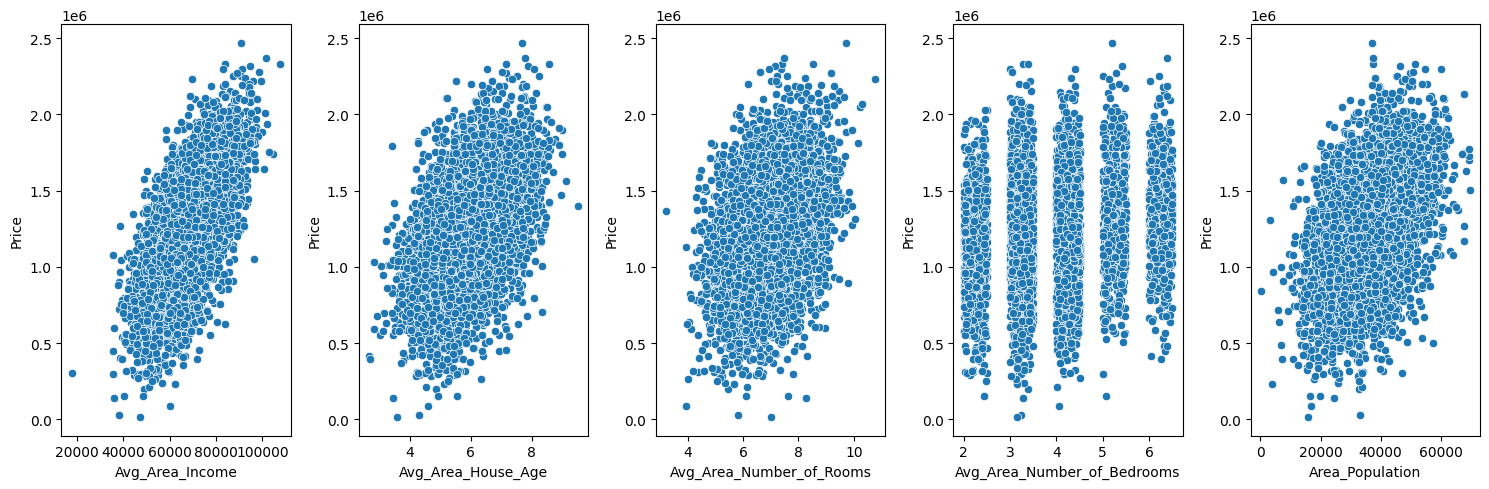

In [29]:
plt.figure(figsize=(15,5))
sns.scatterplot(x='Avg_Area_Income',y='Price',data=df,ax=plt.subplot(1,5,1))
sns.scatterplot(x='Avg_Area_House_Age',y='Price',data=df,ax=plt.subplot(1,5,2))
sns.scatterplot(x='Avg_Area_Number_of_Rooms',y='Price',data=df,ax=plt.subplot(1,5,3))
sns.scatterplot(x='Avg_Area_Number_of_Bedrooms',y='Price',data=df,ax=plt.subplot(1,5,4))
sns.scatterplot(x='Area_Population',y='Price',data=df,ax=plt.subplot(1,5,5))
plt.tight_layout()
plt.show()

<Axes: >

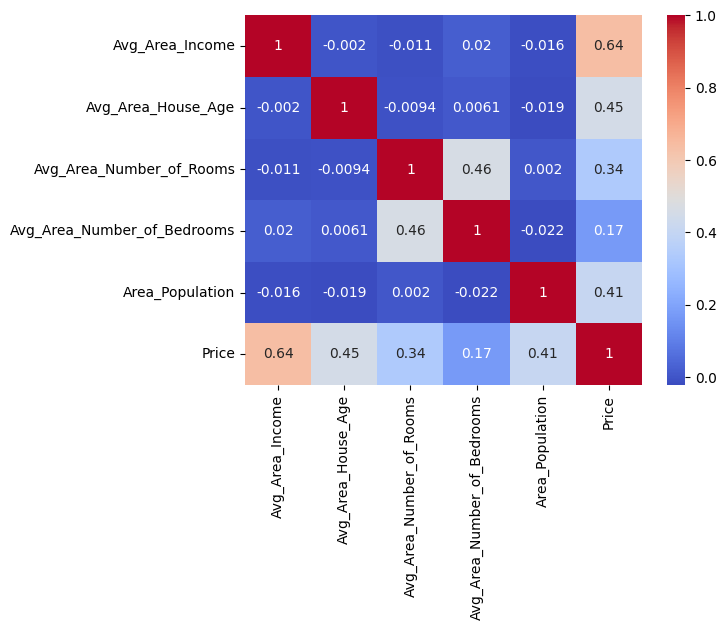

In [30]:
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

In [31]:
X=df.drop('Price', axis=1)
y=df['Price']

In [32]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [33]:
scaler=StandardScaler()
X_train_scaler=scaler.fit_transform(X_train)
X_test_scaler=scaler.transform(X_test)

In [34]:
model=LinearRegression()
model.fit(X_train_scaler,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
from sklearn.model_selection import cross_val_score
cv_scores=cross_val_score(model,X_train_scaler,y_train,cv=5)
print(f'Cross-validation scores: {cv_scores.mean()}')

Cross-validation scores: 0.9174131909728761


In [36]:
y_pred=model.predict(X_test_scaler)

In [37]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
R2=r2_score(y_test,y_pred)
print(f"MAE:{mae}\nMSE:{mse}\nRMSE:{rmse}\nR2:{R2}")

MAE:80879.09723489445
MSE:10089009300.89399
RMSE:100444.06055558482
R2:0.9179971706834331


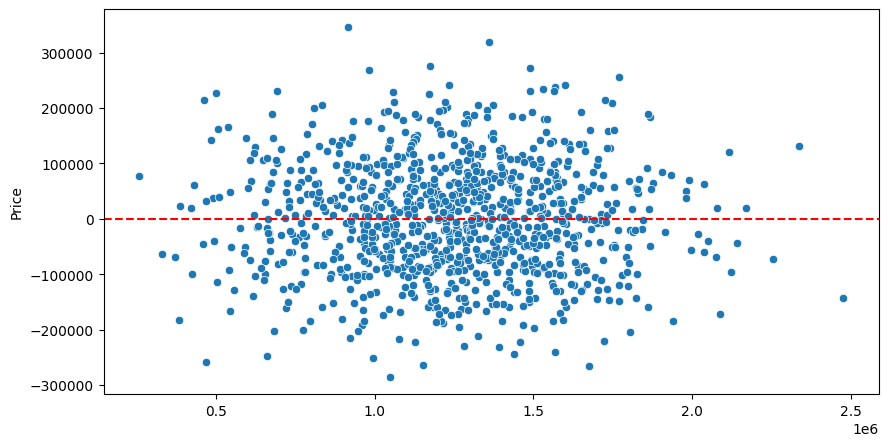

In [38]:
residuals=y_test-y_pred
plt.figure(figsize=(10,5))
sns.scatterplot(x=y_pred,y=residuals)
plt.axhline(0,color='red',linestyle='--')

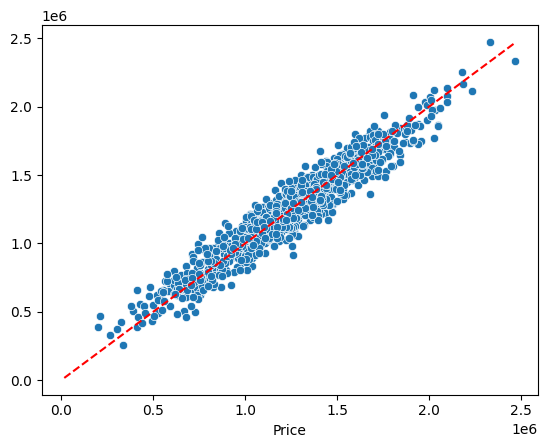

In [39]:
sns.scatterplot(x=y_test,y=y_pred)
plt.plot([y.min(),y.max()],[y.min(),y.max()],color='red',linestyle='--')